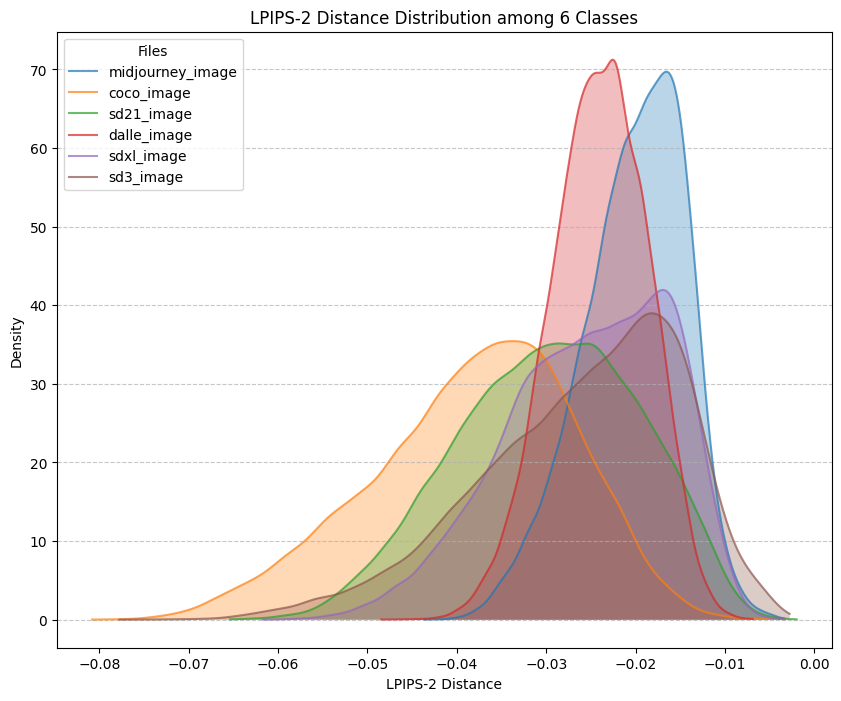

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import gaussian_kde
import numpy as np

plt.figure(figsize=(10, 8))

for class_label in os.listdir(os.path.join("experiment", "train")):
    file_path = os.path.join('experiment', 'train', class_label, "distances.csv")
    
    df = pd.read_csv(file_path)
    distances = df['distance']
    
    kde = gaussian_kde(distances)
    x_vals = np.linspace(distances.min(), distances.max(), 1000)
    y_vals = kde(x_vals)
    
    plt.plot(x_vals, y_vals, label=class_label, alpha=0.7)
    plt.fill_between(x_vals, y_vals, alpha=0.3)

plt.title('LPIPS-2 Distance Distribution among 6 Classes')
plt.xlabel('LPIPS-2 Distance')
plt.ylabel('Density')
plt.legend(title='Files', loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


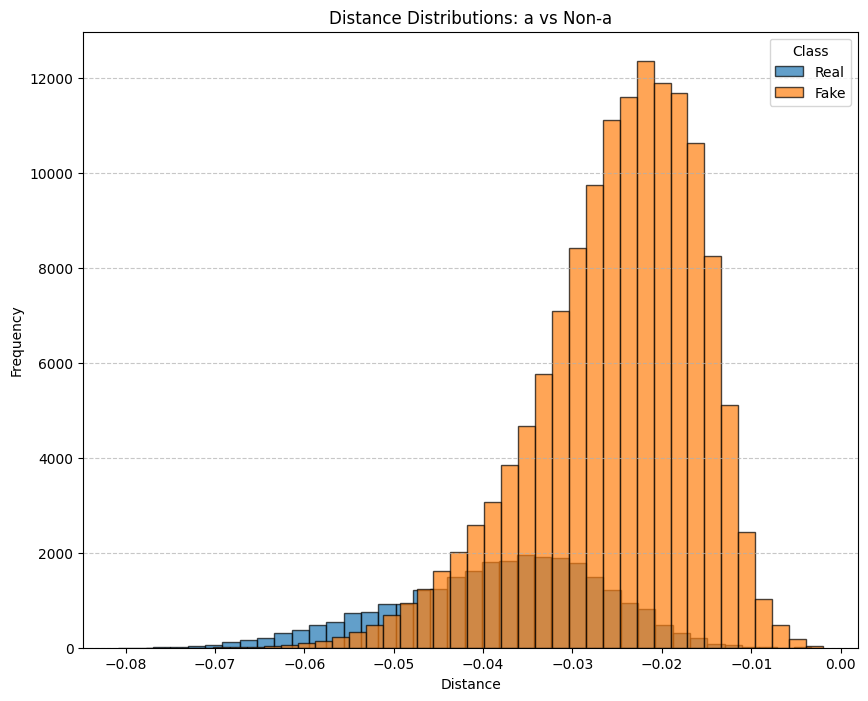

In [ ]:
a_group = []
non_a_group = []

for class_label in os.listdir(os.path.join("experiment", "train")):
    file_path = os.path.join('experiment', 'train', class_label, "distances.csv")
    
    if 'coco' in class_label.lower():
        a_group.extend(df['distance'])
    else:
        df = pd.read_csv(file_path)
        non_a_group.extend(df['distance'])

plt.figure(figsize=(10, 8))

plt.hist(a_group, bins=40, alpha=0.7, label='Real', edgecolor='black')

plt.hist(non_a_group, bins=40, alpha=0.7, label='Fake', edgecolor='black')

plt.title('Distance Distributions: a vs Non-a')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.legend(title='Class', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Compute the final label
based on the threshold, compute the final label

In [5]:
# less than threshold   -> real image
# larger than threshold -> fake image

threshold = -0.035

In [6]:
val_shuffle_df = pd.read_csv(os.path.join("..", "..", "data", "val", "val_shuffle.csv"))
val_shuffle_df.head()

,Caption,Image,Label_A,Label_B
0,a toilet sits next to a shower an sink,/home/nasrin/HPCServer/AIISC/AGID/dataset/COCO...,1,3
1,A TV sitting on top of a table next to a lapto...,/home/nasrin/HPCServer/AIISC/AGID/dataset/COCO...,0,0
2,Two giraffes eat from a pot attached to a fence.,/home/nasrin/HPCServer/AIISC/AGID/dataset/COCO...,1,1
3,The kitchen has many grill with pots hanging a...,/home/nasrin/HPCServer/AIISC/AGID/dataset/COCO...,1,4
4,some road signs besides a road in the street,/home/nasrin/HPCServer/AIISC/AGID/dataset/COCO...,1,1


In [7]:
caption_df = pd.read_excel(os.path.join("..", "..", "data", "val", "captions.xlsx"))
caption_df.head()

,Index,Caption
0,0,a toilet sits next to a shower an sink
1,1,A TV sitting on top of a table next to a lapto...
2,2,Two giraffes eat from a pot attached to a fence.
3,3,The kitchen has many grill with pots hanging a...
4,4,some road signs besides a road in the street


In [8]:
val_distance_df = pd.read_csv(os.path.join('experiment', 'val', "distances.csv"))
val_distance_df.head()

,dir,image_size,repo_id,transform,distance_metric,file,distance
0,../../data/val,512,CompVis/stable-diffusion-v1-1,"Resize(size=[512, 512], interpolation=bilinear...",lpips_vgg_2,0.png,-0.015839
1,../../data/val,512,CompVis/stable-diffusion-v1-1,"Resize(size=[512, 512], interpolation=bilinear...",lpips_vgg_2,1.png,-0.041199
2,../../data/val,512,CompVis/stable-diffusion-v1-1,"Resize(size=[512, 512], interpolation=bilinear...",lpips_vgg_2,10.png,-0.047211
3,../../data/val,512,CompVis/stable-diffusion-v1-1,"Resize(size=[512, 512], interpolation=bilinear...",lpips_vgg_2,100.png,-0.033295
4,../../data/val,512,CompVis/stable-diffusion-v1-1,"Resize(size=[512, 512], interpolation=bilinear...",lpips_vgg_2,1000.png,-0.029144


In [9]:
from tqdm import tqdm

labels = []
preds = []

for filename, distance in zip(val_distance_df["file"], val_distance_df["distance"]):

    index = int(filename.split(".png")[0])
    
    label = val_shuffle_df.loc[index, "Label_A"].item()
    pred = 1 # fake
    if distance <= threshold:
        pred = 0
    
    labels.append(label)
    preds.append(pred)


### Test AEROBLADE performance
- score
- confusion matrix

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

binary_f1 = f1_score(labels, preds, average="binary")
macro_f1 = f1_score(labels, preds, average="macro")
accuracy = accuracy_score(labels, preds)

print(f"Acc: {accuracy:.4f} | Binary_F1: {binary_f1:.4f} | Macro_F1: {macro_f1:.4f}")



Acc: 0.8149 | Binary_F1: 0.8858 | Macro_F1: 0.6986


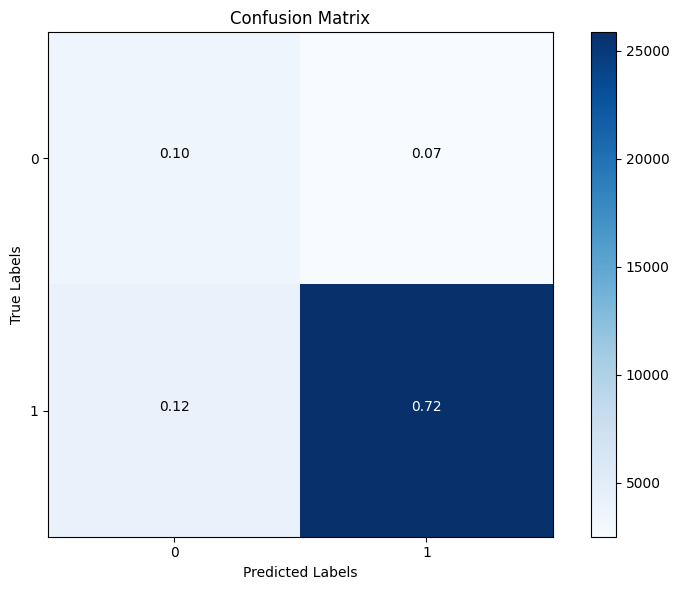

In [11]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

classes = np.unique(labels)
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j] / len(labels), '.2f'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

plt.tight_layout()
plt.show()